--- Run 1 (h = 0.01) ---
This is the 'first run' baseline. Total Accumulated Error: 0.0

--- Run 2 (h = 0.06) ---
Total Accumulated Error: 0.3173
Point-by-point errors: [0.     0.0048 0.0084 0.0111 0.0131 0.0144 0.0153 0.0157 0.0159 0.0158
 0.0154 0.015  0.0144 0.0138 0.0131 0.0124 0.0117 0.0109 0.0102 0.0095
 0.0088 0.0082 0.0076 0.007  0.0064 0.0059 0.0054 0.005  0.0045 0.0042
 0.0038 0.0035 0.0032 0.0029]

--- Run 3 (h = 0.11) ---
Total Accumulated Error: 0.3988
Point-by-point errors: [0.     0.019  0.0299 0.0354 0.0373 0.0368 0.0349 0.0321 0.029  0.0258
 0.0226 0.0196 0.0169 0.0145 0.0123 0.0104 0.0088 0.0074 0.0062]

--- Run 4 (h = 0.16) ---
Total Accumulated Error: 0.3498
Point-by-point errors: [0.     0.0341 0.0476 0.0497 0.0463 0.0403 0.0338 0.0275 0.0219 0.0172
 0.0134 0.0103 0.0078]

--- Run 5 (h = 0.21) ---
Total Accumulated Error: 0.3630
Point-by-point errors: [0.     0.0583 0.071  0.065  0.0528 0.0403 0.0296 0.0211 0.0147 0.0102]

--- Run 6 (h = 0.26) ---
Total Accumulated

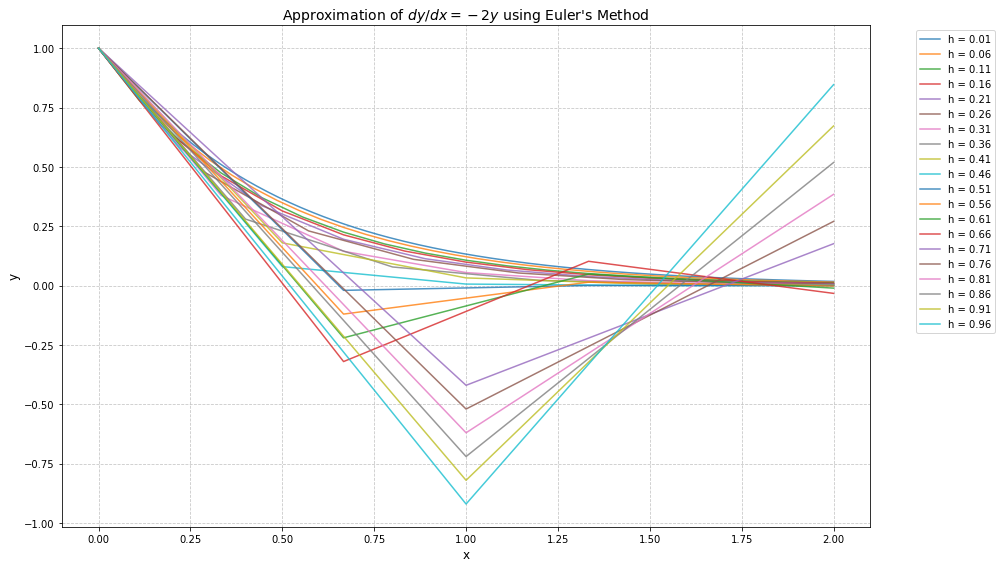

In [2]:
import numpy as np
import matplotlib.pyplot as plt

x_start, x_end = 0, 2

# Function representing dy/dx = -2y
def f(x, y):
    return -2 * y

# loop(range) step size to go from .01 to 1, steps of .05
# Use np.arange to create an array
step_sizes = np.arange(0.01, 1.01, 0.05)

# Variables to store the 'first run' for error comparison
first_run_x = None
first_run_y = None

# Configure plot
plt.figure(figsize=(14, 8))
np.set_printoptions(precision=4, suppress=True) # Makes the printed arrays easier to read

for i, h in enumerate(step_sizes):
    # Calculate number of steps for the current step size
    num_steps = int((x_end - x_start) / h)
    
    # Generate x and y arrays
    x_values = np.linspace(x_start, x_end, num_steps + 1)
    y_values = np.zeros(num_steps + 1)
    
    # Initial condition
    y_values[0] = 1  # y(0) = 1
    
    # Implement Euler's method
    for j in range(num_steps):
        y_values[j + 1] = y_values[j] + h * f(x_values[j], y_values[j])
        
    # Plot the results for this step size
    plt.plot(x_values, y_values, label=f"h = {h:.2f}", alpha=0.8)
    
    # Error Calculation (Current Run vs First Run)
    if i == 0:
        # Save the first run to act as our baseline
        first_run_x = x_values
        first_run_y = y_values
        print(f"--- Run 1 (h = {h:.2f}) ---")
        print("This is the 'first run' baseline. Total Accumulated Error: 0.0\n")
    else:
        # Interpolate the baseline y-values to match the current run's x-values
        # This is necessary because different step sizes sample at different x-coordinates
        baseline_y = np.interp(x_values, first_run_x, first_run_y)
        
        # Calculate error for each point
        point_errors = np.abs(y_values - baseline_y)
        total_accumulated_error = np.sum(point_errors)
        
        print(f"--- Run {i+1} (h = {h:.2f}) ---")
        print(f"Total Accumulated Error: {total_accumulated_error:.4f}")
        print(f"Point-by-point errors: {point_errors}\n")

# Format the plot
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title("Approximation of $dy/dx = -2y$ using Euler's Method", fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Moves legend outside to avoid hiding lines
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Show the plot
plt.show()